# Toxicity Model Training

This notebook starts from `toxicity_all.csv`, applies a clearly editable training filter, builds graph features with taxonomy metadata, trains the model, and then checks the results in a few different ways.


## 1. Setup

Import the training modules and keep the notebook focused on the model pipeline.


In [20]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the project root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch_geometric.loader import DataLoader
from torch_geometric.utils.smiles import from_smiles

from src.data.io import load_data
from src.data.cleaning import print_mol_types
from src.data.graph_building import build_graph_features
from src.data.metadata import sequential_encoder, build_config
from src.data.cleaning import mask_data, preprocess
from src.training.loops import train
from src.models.attentive_fp import AttentiveFP
from src.models.toxicity_model import ToxicityModel
from src.models.meta_encoder import MetaEncoder, TaxonomyEncoder, TaxonomyOneHot
from src.visualization.training_plots import plot_toxicity_distribution, plot_training
from src.data.splitting import butina_split, generate_scaffold

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 80)

DATA_PATH = PROJECT_ROOT / "Data" / "toxicity_all.csv"

print("Setup complete")
print(f"Data file: {DATA_PATH}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Setup complete
Data file: /home/vollmers/gnn-thesis/Data/toxicity_all.csv


## 2. Load And Filter The Training Slice

The defaults below create a coherent starting dataset for modeling: fish-only, `EC50`, `mg/L`, and hour-based durations. Change these values in this cell when you want a different training subset.


In [2]:
selected_columns = [
    # "SK_unique_id",
    # "data_source",
    "SMILES",
    "conc",
    "conc_unit",
    # "conc_sign",
    "duration",
    "duration_unit",
    "endpoint",
    "effect",
    "species_group",
    "species_latin_name",
    "NCBI_rank_class",
    "NCBI_rank_family",
    "NCBI_rank_genus",
    "NCBI_rank_species",
]

df_all = load_data(DATA_PATH, selected_columns)

# Filters
filters = {
    "conc_unit": ["mg/L"],
    "duration_unit": ["h"],
    # "endpoint": ["EC50"],
    # "effect": ["MOR"],
}
require_duration = True
require_taxonomy = True

taxonomy_cols = (
    "NCBI_rank_class",
    "NCBI_rank_family",
    "NCBI_rank_genus",
    "NCBI_rank_species",
)

max_rows = 10000  # set to an integer like 15000 for faster experiments
# max_rows = None
random_state = 11

# Create mask
mask = mask_data(
    df_all,
    filters=filters,
    require_duration=require_duration,
    require_taxonomy=require_taxonomy,
    taxonomy_columns=taxonomy_cols,
)

# Apply mask and filter
df_filtered = df_all.loc[mask].copy()

# Optionally limit the number of rows for faster experiments
if max_rows is not None and len(df_filtered) > max_rows:
    df_filtered = df_filtered.sample(n=max_rows, random_state=random_state).reset_index(drop=True)
else:
    df_filtered = df_filtered.reset_index(drop=True)

# Convert taxonomy columns to numeric, coercing errors to NaN and then to nullable Int64
for col in taxonomy_cols:
    df_filtered[col] = pd.to_numeric(df_filtered[col], errors="coerce").astype("Int64")

df_filtered = df_filtered.rename(columns={
    "NCBI_rank_species": "taxid",
    "NCBI_rank_genus": "genus",
    "NCBI_rank_family": "family",
    "NCBI_rank_class": "class",
})

print()
print("Loaded and filtered training data")
print(f"Rows in full selected table: {len(df_all):,}")
print(f"Rows after filter: {len(df_filtered):,}")
print()
print("Filtered preview")
print(df_filtered.head())


Filters
conc_unit: ['mg/L']
True: 0.460
duration_unit: ['h']
True: 0.745
require_duration: True
True: 0.764
require_taxonomy: True
True: 0.916

Loaded and filtered training data
Rows in full selected table: 561,100
Rows after filter: 10,000

Filtered preview
                          SMILES      conc conc_unit  duration duration_unit  \
0  CC(C)(C)C1CCC2(CC1)OCC(CCl)O2    0.4400      mg/L      96.0             h   
1    Oc1c(Cl)c(Cl)c(Cl)c(Cl)c1Cl    0.0540      mg/L      96.0             h   
2         O=[N+]([O-])[O-].[Ag+]    0.0076      mg/L      96.0             h   
3       O=S(=O)([O-])[O-].[Mg+2]  861.0000      mg/L      72.0             h   
4   COc1nn(CSP(=S)(OC)OC)c(=O)s1    7.4000      mg/L      48.0             h   

  endpoint effect species_group           species_latin_name   class   family  \
0     LOEC    MOR          fish          oncorhynchus mykiss  186623     8015   
1     EC50    MOR          fish  salmo trutta ssp. lacustris  186623     8015   
2     EC50    MOR

## 3. Preprocess Molecules And Targets

Apply the molecular cleaning choices here and create the `log10c` target that the model will learn.


In [3]:
df_processed = preprocess(
    df_filtered.copy(),
    split_salts=False,
    remove_lone=False,
    remove_metals=False,
)

print(f"Rows before preprocessing: {len(df_filtered):,}")
print(f"Rows after preprocessing:  {len(df_processed):,}")
print(f"Rows removed: {len(df_filtered) - len(df_processed):,}")
print()
print("Preprocessed preview")
print(df_processed[["SMILES", "conc", "log10c"]].head())
print()
print_mol_types(df_processed)


Rows before preprocessing: 10,000
Rows after preprocessing:  10,000
Rows removed: 0

Preprocessed preview
                          SMILES      conc    log10c
0  CC(C)(C)C1CCC2(CC1)OCC(CCl)O2    0.4400 -0.356547
1    Oc1c(Cl)c(Cl)c(Cl)c(Cl)c1Cl    0.0540 -1.267606
2         O=[N+]([O-])[O-].[Ag+]    0.0076 -2.119186
3       O=S(=O)([O-])[O-].[Mg+2]  861.0000  2.935003
4   COc1nn(CSP(=S)(OC)OC)c(=O)s1    7.4000  0.869232



[13:16:52] WARNING: not removing hydrogen atom without neighbors
[13:16:52] WARNING: not removing hydrogen atom without neighbors
[13:16:52] WARNING: not removing hydrogen atom without neighbors
[13:16:52] WARNING: not removing hydrogen atom without neighbors
[13:16:53] WARNING: not removing hydrogen atom without neighbors
[13:16:53] WARNING: not removing hydrogen atom without neighbors


Total molecules: 10000
Unique molecules: 2577
Salts: 2623, 26.23%
Single atoms: 40, 0.40%
Metals: 3022, 30.22%


## 4. Handle Data and Metadata

Turn the filtered table into molecular graphs, encode the taxonomy columns and handle other metadata


In [4]:
# Molecular featurizer
df_processed["features"] = df_processed["SMILES"].apply(from_smiles)

sample_id = min(16, len(df_processed) - 1)

# Taxonomy encoding
embedding_size = {
    "taxid": 16,
    "genus": 8,
    "family": 8,
    "class": 4,
}

df_tax = df_processed[list(embedding_size.keys())].copy()
df_tax, encoders = sequential_encoder(df_tax, embedding_size.keys())

config_tax = build_config(df_tax, embedding_size)
taxid_decoder = {encoded: original for original, encoded in encoders["taxid"].items()}
taxid_lookup = (
    df_processed[["taxid", "species_latin_name"]]
    .dropna(subset=["taxid", "species_latin_name"])
    .drop_duplicates(subset=["taxid"])
    .set_index("taxid")["species_latin_name"]
    .to_dict()
)

print("Taxonomy embedding config")
print(config_tax)
print()

# Categorical encoding
categorical_cols = ["endpoint", "effect"]

df_categorical = df_processed[categorical_cols].copy()
df_categorical, categorical_encoders = sequential_encoder(df_categorical, categorical_cols)

config_categorical = build_config(df_categorical, categorical_cols)

print("Categorical embedding config")
print(config_categorical)


Taxonomy embedding config
{'taxid': (1401, 16), 'genus': (979, 8), 'family': (557, 8), 'class': (86, 4)}

Categorical embedding config
{'endpoint': 5, 'effect': 11}


## 5. Build The Final Graph Dataset

Attach the normalized target input columns and taxonomy ids to each PyG graph object.


In [5]:
features = build_graph_features(df_processed, df_tax, embedding_size, df_categorical)

sample_feature = features[sample_id]

print(f"Graph objects created: {len(features):,}")
print()
print("Info for a sample:")
print(features[sample_id])


Graph objects created: 10,000

Info for a sample:
Data(x=[3, 9], edge_index=[2, 4], edge_attr=[4, 3], smiles='Cl[Cd]Cl', y=1.6989699602127075, taxid=12, genus=12, family=10, class=6, endpoint=2, effect=1, duration=48.0)


## 6. Split The Dataset

Use the same split style as before, but keep the split settings in this cell so they are easy to change in context.


In [ ]:
split_method = "butina"
frac_train = 0.7
frac_valid = 0.1
frac_test = 0.2

train_dataset, test_dataset, val_dataset = butina_split(
    features,
    frac_train=frac_train,
    frac_test=frac_test,
    frac_valid=frac_valid,
)

train_targets_before = np.array([g.y.item() for g in train_dataset])
val_targets_before = np.array([g.y.item() for g in val_dataset])
test_targets_before = np.array([g.y.item() for g in test_dataset])
train_smiles = [g.smiles for g in train_dataset]
val_smiles = [g.smiles for g in val_dataset]
test_smiles = [g.smiles for g in test_dataset]

print(f"Split method: {split_method}")
print(f"Train size: {len(train_dataset):,} ({len(train_dataset) / len(features):.1%})")
print(f"Val size:   {len(val_dataset):,} ({len(val_dataset) / len(features):.1%})")
print(f"Test size:  {len(test_dataset):,} ({len(test_dataset) / len(features):.1%})")
print()
print(f"Unique molecules in train: {len(set(train_smiles)):,}")
print(f"Unique molecules in val:   {len(set(val_smiles)):,}")
print(f"Unique molecules in test:  {len(set(test_smiles)):,}")
print(f"Val molecules not in train:  {len(set(val_smiles) - set(train_smiles)):,}")
print(f"Test molecules not in train: {len(set(test_smiles) - set(train_smiles)):,}")
print()
print("Target distribution before normalization")
print(f"Train mean/std: {train_targets_before.mean():.4f} / {train_targets_before.std():.4f}")
print(f"Val mean/std:   {val_targets_before.mean():.4f} / {val_targets_before.std():.4f}")
print(f"Test mean/std:  {test_targets_before.mean():.4f} / {test_targets_before.std():.4f}")


Split method: butina
Train fraction: 0.7
Val fraction:   0.1
Test fraction:  0.2
Train size: 6,996 (70.0%)
Val size:   1,003 (10.0%)
Test size:  2,001 (20.0%)

Unique molecules in train: 886
Unique molecules in val:   615
Unique molecules in test:  1,535
Val molecules not in train:  391
Test molecules not in train: 1,392

Target distribution before normalization
Train mean/std: -0.1494 / 1.8468
Val mean/std:   0.4354 / 1.8903
Test mean/std:  0.5880 / 1.6206


## 7. Normalize The Target

Normalize with training-set statistics only, then verify the train and test target distributions.


Mean used: -0.1494
Std used:  1.8468

Target distribution after normalization
Train mean/std: 0.0000 / 1.0000
Val mean/std:   0.3167 / 1.0235
Test mean/std:  0.3993 / 0.8775


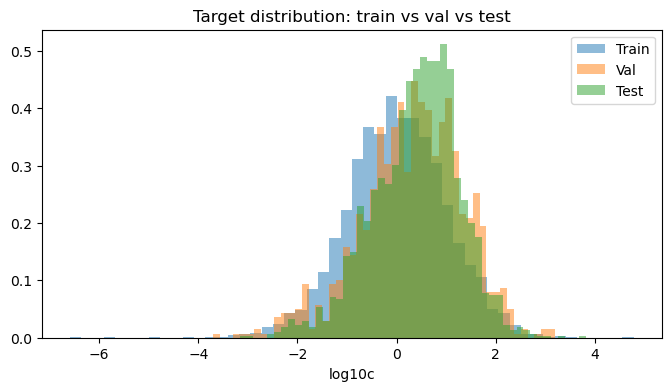

Train mean: 0.00, std: 1.00
Val mean:   0.32, std: 1.02
Test mean:  0.40,  std: 0.88


In [7]:
target_mean = train_targets_before.mean()
target_std = train_targets_before.std()

for dataset in (train_dataset, val_dataset, test_dataset):
    for g in dataset:
        g.y = (g.y - target_mean) / target_std

train_targets_after = np.array([g.y.item() for g in train_dataset])
val_targets_after = np.array([g.y.item() for g in val_dataset])
test_targets_after = np.array([g.y.item() for g in test_dataset])

print(f"Mean used: {target_mean:.4f}")
print(f"Std used:  {target_std:.4f}")
print()
print("Target distribution after normalization")
print(f"Train mean/std: {train_targets_after.mean():.4f} / {train_targets_after.std():.4f}")
print(f"Val mean/std:   {val_targets_after.mean():.4f} / {val_targets_after.std():.4f}")
print(f"Test mean/std:  {test_targets_after.mean():.4f} / {test_targets_after.std():.4f}")

plot_toxicity_distribution(train_dataset, test_dataset, val_dataset=val_dataset)


## 8. Build DataLoaders

Create batches and inspect the first batch so the shapes are visible before training starts.


In [8]:
batch_size = 256

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

first_batch = next(iter(train_loader))

print(f"Batch size: {batch_size}")
print(f"Train batches per epoch: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")
print()
print("First batch summary")
print(f"Graphs in batch: {first_batch.num_graphs}")
print(f"x shape: {tuple(first_batch.x.shape)}")
print(f"edge_index shape: {tuple(first_batch.edge_index.shape)}")
print(f"edge_attr shape: {tuple(first_batch.edge_attr.shape)}")
print(f"y shape: {tuple(first_batch.y.shape)}")


Batch size: 256
Train batches per epoch: 28
Val batches: 4
Test batches: 8

First batch summary
Graphs in batch: 256
x shape: (3436, 9)
edge_index shape: (2, 6588)
edge_attr shape: (6588, 3)
y shape: (256,)


## 9. Build The Model

Graph encoder, metadata encoder, and a final toxicity predictor.


In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUMERIC_OUTPUT_DIM = 16
TAX_OUTPUT_DIM = 64
CATEGORICAL_OUTPUT_DIM = 16

GNN_HIDDEN_DIM = 64
GNN_OUT_DIM = 64

NUM_LAYERS = 2
NUM_TIMESTEPS = 2
DROPOUT = 0.4
FINAL_HIDDEN_DIM = 64

meta_encoder = MetaEncoder(
    numeric_output_dim=NUMERIC_OUTPUT_DIM,
    tax_output_dim=TAX_OUTPUT_DIM,
    categorical_output_dim=CATEGORICAL_OUTPUT_DIM,
    taxonomy_encoder_cls=TaxonomyEncoder,
    config_tax=config_tax,
    config_categorical=config_categorical,
).to(device)

model_gnn = AttentiveFP(
    in_channels=9,
    edge_dim=3,
    hidden_channels=GNN_HIDDEN_DIM,
    out_channels=GNN_OUT_DIM,
    num_layers=NUM_LAYERS,
    num_timesteps=NUM_TIMESTEPS,
    dropout=DROPOUT,
).to(device)

model = ToxicityModel(
    model_gnn,
    meta_encoder,
    hidden_dim=FINAL_HIDDEN_DIM,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Device: {device}")
print(f"Trainable parameters: {n_params:,}")
print()
print(model)


Device: cpu
Trainable parameters: 145,049

ToxicityModel(
  (gnn): AttentiveFP(
    (lin1): Linear(in_features=9, out_features=64, bias=True)
    (gate_conv): GATEConv()
    (gru): GRUCell(64, 64)
    (atom_convs): ModuleList(
      (0): GATConv(64, 64, heads=1)
    )
    (atom_grus): ModuleList(
      (0): GRUCell(64, 64)
    )
    (mol_conv): GATConv(64, 64, heads=1)
    (mol_gru): GRUCell(64, 64)
    (lin2): Linear(in_features=64, out_features=64, bias=True)
  )
  (meta_encoder): MetaEncoder(
    (encoder_numeric): NumericalEncoder(
      (projection): Sequential(
        (0): Linear(in_features=1, out_features=16, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.2, inplace=False)
      )
    )
    (encoder_tax): TaxonomyEncoder(
      (embeddings): ModuleDict(
        (taxid): Embedding(1401, 16)
        (genus): Embedding(979, 8)
        (family): Embedding(557, 8)
        (class): Embedding(86, 4)
      )
      (projection): Sequential(
        (0): Linear(in_features=36, 

## 10. Train The Model

Start with a stable optimizer/scheduler pairing that matches the current training utility.


Training configuration
epochs = 50
learning_rate = 0.0003
weight_decay = 0.0001
loss = SmoothL1Loss
early_stopping_patience = 20
Epoch 0: Train Loss = 0.5796, Val Loss = 0.6484, Val RMSE = 1.0779, Val MAE = 0.8678, Test Loss = 0.5991, Test RMSE = 1.0114, Test MAE = 0.8246
Epoch 10: Train Loss = 0.5129, Val Loss = 0.5494, Val RMSE = 0.9738, Val MAE = 0.7650, Test Loss = 0.5211, Test RMSE = 0.9264, Test MAE = 0.7389
Epoch 20: Train Loss = 0.4846, Val Loss = 0.5322, Val RMSE = 0.9593, Val MAE = 0.7455, Test Loss = 0.5154, Test RMSE = 0.9227, Test MAE = 0.7328
Epoch 30: Train Loss = 0.4640, Val Loss = 0.5142, Val RMSE = 0.9458, Val MAE = 0.7234, Test Loss = 0.5052, Test RMSE = 0.9123, Test MAE = 0.7225
Epoch 40: Train Loss = 0.4500, Val Loss = 0.5058, Val RMSE = 0.9425, Val MAE = 0.7151, Test Loss = 0.5198, Test RMSE = 0.9343, Test MAE = 0.7362


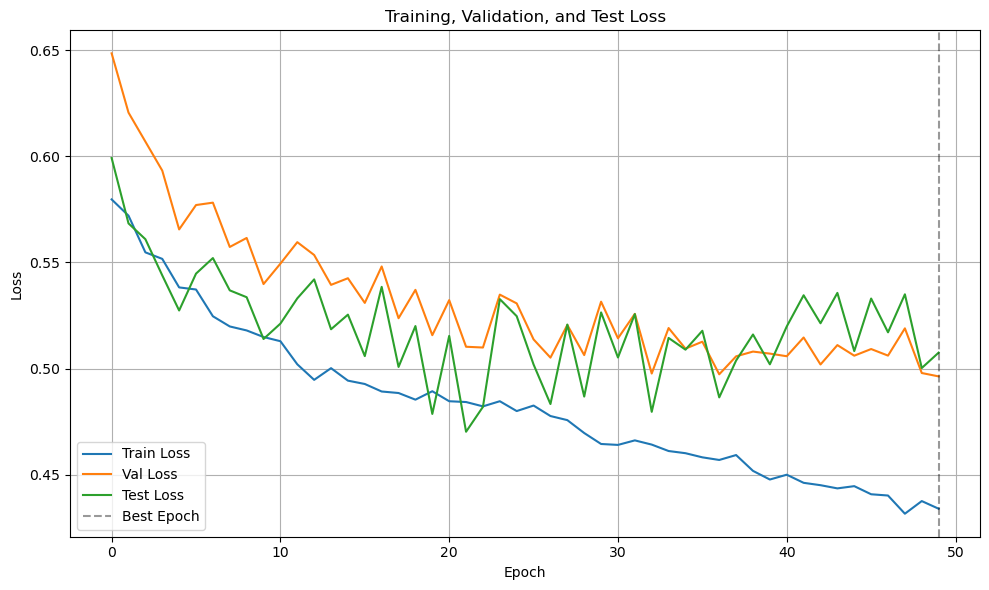

In [17]:
epochs = 50
learning_rate = 3e-4
weight_decay = 1e-4
loss_beta = 0.5
early_stopping_patience = 20
early_stopping_min_delta = 1e-4

loss_fn = torch.nn.SmoothL1Loss(beta=loss_beta)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=10,
    factor=0.5,
    min_lr=1e-6,
)

print("Training configuration")
print(f"epochs = {epochs}")
print(f"learning_rate = {learning_rate}")
print(f"weight_decay = {weight_decay}")
print(f"loss = {loss_fn.__class__.__name__}")
print(f"early_stopping_patience = {early_stopping_patience}")

model_trained, history = train(
    model,
    train_loader,
    test_loader=test_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=epochs,
    device=device,
    early_stopping_patience=early_stopping_patience,
    early_stopping_min_delta=early_stopping_min_delta,
)

model = model_trained
plot_training(history)


## 11. Check Overall Test Performance

Report the main metrics and keep both normalized and denormalized outputs available for later inspection.


In [20]:
preds_norm = []
targets_norm = []
encoded_taxids = []
smiles_test = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        pred = model(batch).squeeze()
        preds_norm.extend(pred.cpu().numpy())
        targets_norm.extend(batch.y.cpu().numpy())
        encoded_taxids.extend(batch.taxid.cpu().numpy())
        smiles_test.extend(batch.smiles)

preds_norm = np.array(preds_norm)
targets_norm = np.array(targets_norm)
preds_log10c = preds_norm * target_std + target_mean
targets_log10c = targets_norm * target_std + target_mean

results_df = pd.DataFrame({
    "smiles": smiles_test,
    "pred_norm": preds_norm,
    "actual_norm": targets_norm,
    "pred_log10c": preds_log10c,
    "actual_log10c": targets_log10c,
    "encoded_taxid": encoded_taxids,
})
results_df["taxid"] = results_df["encoded_taxid"].astype(int).map(taxid_decoder)
results_df["species_latin_name"] = results_df["taxid"].map(taxid_lookup)
results_df["pred_conc"] = np.power(10.0, results_df["pred_log10c"])
results_df["actual_conc"] = np.power(10.0, results_df["actual_log10c"])
results_df["abs_error_log10c"] = (results_df["pred_log10c"] - results_df["actual_log10c"]).abs()
results_df["residual_log10c"] = results_df["pred_log10c"] - results_df["actual_log10c"]
results_df["fold_error"] = np.maximum(
    results_df["pred_conc"] / results_df["actual_conc"],
    results_df["actual_conc"] / results_df["pred_conc"],
)

print("Overall test-set metrics")
print(f"R^2 (normalized target): {r2_score(results_df['actual_norm'], results_df['pred_norm']):.3f}")
print(f"R^2 (log10c): {r2_score(results_df['actual_log10c'], results_df['pred_log10c']):.3f}")
print(f"RMSE (log10c): {mean_squared_error(results_df['actual_log10c'], results_df['pred_log10c']) ** 0.5:.3f}")
print(f"MAE (log10c): {mean_absolute_error(results_df['actual_log10c'], results_df['pred_log10c']):.3f}")
print(f"Median fold error (conc scale): {results_df['fold_error'].median():.3f}")
print()
print("Largest errors on the test set")
print(
    results_df[["species_latin_name", "taxid", "actual_log10c", "pred_log10c", "abs_error_log10c", "fold_error", "smiles"]]
    .sort_values("abs_error_log10c", ascending=False)
    .head(10)
    .to_string(index=False)
)


NameError: name 'taxid_lookup' is not defined

## 12. Visual Result Checks

Look at prediction-vs-actual and residual behavior, not just aggregate metrics.


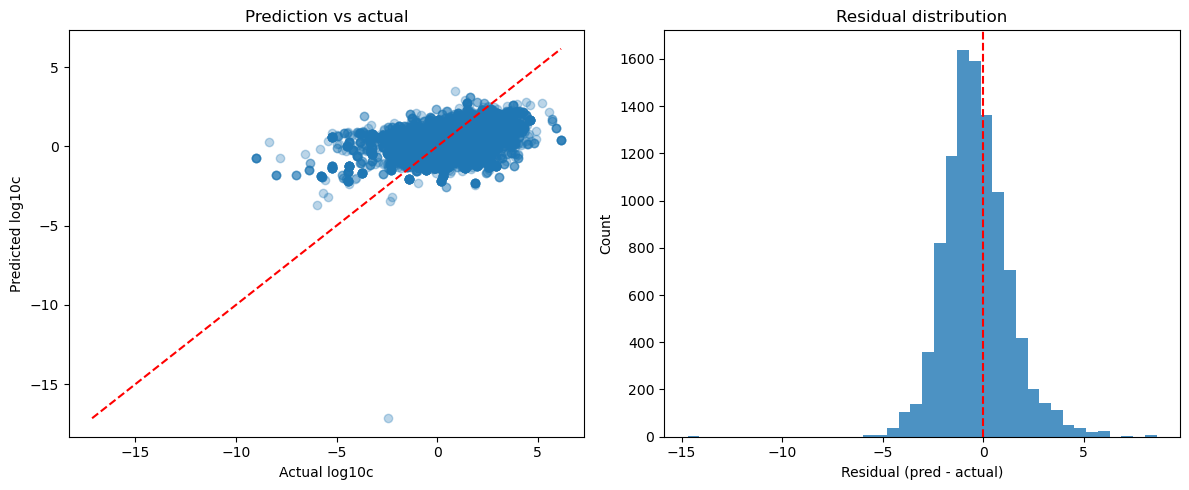

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(results_df["actual_log10c"], results_df["pred_log10c"], alpha=0.3)
plot_min = min(results_df["actual_log10c"].min(), results_df["pred_log10c"].min())
plot_max = max(results_df["actual_log10c"].max(), results_df["pred_log10c"].max())
axes[0].plot([plot_min, plot_max], [plot_min, plot_max], "r--")
axes[0].set_xlabel("Actual log10c")
axes[0].set_ylabel("Predicted log10c")
axes[0].set_title("Prediction vs actual")

axes[1].hist(results_df["residual_log10c"], bins=40, alpha=0.8)
axes[1].axvline(0, color="r", linestyle="--")
axes[1].set_xlabel("Residual (pred - actual)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution")

plt.tight_layout()
plt.show()


## 13. Grouped Checks After Training

Check whether performance changes by scaffold or by species so the model is not only good on average.


In [ ]:
results_df["scaffold"] = results_df["smiles"].apply(generate_scaffold)

scaffold_summary = results_df.groupby("scaffold").apply(
    lambda g: pd.Series({
        "n": len(g),
        "r2": r2_score(g["actual_log10c"], g["pred_log10c"]) if len(g) > 1 else np.nan,
        "mae_log10c": mean_absolute_error(g["actual_log10c"], g["pred_log10c"]),
    })
).sort_values(["n", "mae_log10c"], ascending=[False, True])

species_summary = results_df.dropna(subset=["taxid"]).groupby(["taxid", "species_latin_name"]).apply(
    lambda g: pd.Series({
        "n": len(g),
        "r2": r2_score(g["actual_log10c"], g["pred_log10c"]) if len(g) > 1 else np.nan,
        "mae_log10c": mean_absolute_error(g["actual_log10c"], g["pred_log10c"]),
    })
).sort_values(["n", "mae_log10c"], ascending=[False, True])

print("Scaffold summary")
print(scaffold_summary.head(15).to_string())
print()
print("Species summary")
print(species_summary.head(15).to_string())


/tmp/ipykernel_1685639/928478231.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  scaffold_summary = results_df.groupby("scaffold").apply(


Step 11: Scaffold summary
                            n         r2  mae_log10c
scaffold                                            
c1ccccc1               1608.0   0.067259    1.091915
C1CCCCC1                158.0  -0.059437    1.259662
c1ccncc1                124.0   0.056427    1.735621
c1ccc2ccccc2c1           91.0  -0.029439    0.911078
c1ccc(Cc2ccccc2)cc1      84.0   0.011731    0.802890
C1CO1                    65.0  -0.058375    1.035200
c1ccc(-c2ccccc2)cc1      56.0   0.310066    0.353133
c1ccc(Oc2ccccc2)cc1      53.0  -0.013081    0.960055
C1=CCCCC1                50.0   0.116366    1.890739
c1ccc(Nc2ccccc2)cc1      47.0   0.012808    1.653702
O=C(c1ccccc1)c1ccccc1    42.0  -0.291684    1.071968
c1ncncn1                 39.0  -0.116305    1.263506
c1ccc2scnc2c1            38.0  -0.121250    1.387137
O=c1ccs[nH]1             37.0 -12.105425    1.838841
c1ccc(N=Nc2ccccc2)cc1    35.0  -1.368437    1.391028

Step 12: Species summary
                                           n   

/tmp/ipykernel_1685639/928478231.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  species_summary = results_df.dropna(subset=["taxid"]).groupby(["taxid", "species_latin_name"]).apply(
